In [1]:
import coffea
from coffea import util
import numpy as np
import pandas as pd
import itertools
import os
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("CMS")


## analysis categories

In [2]:
# analysis categories #
# ttagcats = ["AT&Pt", "at", "pret", "0t", "1t", ">=1t", "2t", ">=0t"]
ttagcats = ["at", "pret", "2t"]
btagcats = ["0b", "1b", "2b"]
ycats = ['cen', 'fwd']

anacats = [ t+b+y for t,b,y in itertools.product( ttagcats, btagcats, ycats) ]
label_dict = {i: label for i, label in enumerate(anacats)}
label_to_int_dict = {label: i for i, label in enumerate(anacats)}
print(label_dict)
# print(label_to_int_dict)

{0: 'at0bcen', 1: 'at0bfwd', 2: 'at1bcen', 3: 'at1bfwd', 4: 'at2bcen', 5: 'at2bfwd', 6: 'pret0bcen', 7: 'pret0bfwd', 8: 'pret1bcen', 9: 'pret1bfwd', 10: 'pret2bcen', 11: 'pret2bfwd', 12: '2t0bcen', 13: '2t0bfwd', 14: '2t1bcen', 15: '2t1bfwd', 16: '2t2bcen', 17: '2t2bfwd'}


In [3]:
# label_dict

## directories for saving files

In [4]:
save_csv_filename = 'mistag_rate.csv'


directories = [
    '../plots/images/png/mistagRate/2016all',
    '../plots/images/png/mistagRate/2016APV',
    '../plots/images/png/mistagRate/2016',
    '../plots/images/png/mistagRate/2017',
    '../plots/images/png/mistagRate/2018',
    '../plots/images/pdf/mistagRate/2016all',
    '../plots/images/pdf/mistagRate/2016APV',
    '../plots/images/pdf/mistagRate/2016',
    '../plots/images/pdf/mistagRate/2017',
    '../plots/images/pdf/mistagRate/2018',
    '../plots/images/png/mistagRateQCD/2016all',
    '../plots/images/png/mistagRateQCD/2016APV',
    '../plots/images/png/mistagRateQCD/2016',
    '../plots/images/png/mistagRateQCD/2017',
    '../plots/images/png/mistagRateQCD/2018',
    '../plots/images/pdf/mistagRateQCD/2016all',
    '../plots/images/pdf/mistagRateQCD/2016APV',
    '../plots/images/pdf/mistagRateQCD/2016',
    '../plots/images/pdf/mistagRateQCD/2017',
    '../plots/images/pdf/mistagRateQCD/2018',
    '../data/corrections/backgroundEstimate'
]

for path in directories:
    if not os.path.exists(path):
        os.makedirs(path)
        




## load coffea files

In [5]:
useDeepAK8 = False
IOV = '2016APV'

deepak8str = ''
if useDeepAK8:
    deepak8str = '_DeepAK8'
    
coffea_dir = '../outputs/'
coffeaFiles = {
    "JetHT":{
        "2016APV": {
            "B": coffea_dir+'JetHT_2016APVB'+deepak8str+'.coffea',
            "C": coffea_dir+'JetHT_2016APVC'+deepak8str+'.coffea',
            "D": coffea_dir+'JetHT_2016APVD'+deepak8str+'.coffea',
            "E": coffea_dir+'JetHT_2016APVE'+deepak8str+'.coffea',
            "F": coffea_dir+'JetHT_2016APVF'+deepak8str+'.coffea'
        },
        "2016": {
            "F": coffea_dir+'JetHT_2016F'+deepak8str+'.coffea',
            "G": coffea_dir+'JetHT_2016G'+deepak8str+'.coffea',
            "H": coffea_dir+'JetHT_2016H'+deepak8str+'.coffea'
        },
        "2017": {
            "B": coffea_dir+'JetHT_2017B'+deepak8str+'.coffea',
            "C": coffea_dir+'JetHT_2017C'+deepak8str+'.coffea',
            "D": coffea_dir+'JetHT_2017D'+deepak8str+'.coffea',
            "E": coffea_dir+'JetHT_2017E'+deepak8str+'.coffea',
            "F": coffea_dir+'JetHT_2017F'+deepak8str+'.coffea'
        },
        "2018": {
            "A": coffea_dir+'JetHT_2018A'+deepak8str+'.coffea',
            "B": coffea_dir+'JetHT_2018B'+deepak8str+'.coffea',
            "C": coffea_dir+'JetHT_2018C'+deepak8str+'.coffea',
            "D": coffea_dir+'JetHT_2018D'+deepak8str+'.coffea'
        }
    },
    
    "TTbar": {
        "2016APV": {
            "700to1000": coffea_dir+'TTbar_2016APV_700to1000_noSyst'+deepak8str+'.coffea',
            "1000toInf": coffea_dir+'TTbar_2016APV_1000toInf_noSyst'+deepak8str+'.coffea'
        },
        "2016": {
            "700to1000": coffea_dir+'TTbar_2016_700to1000_noSyst'+deepak8str+'.coffea',
            "1000toInf": coffea_dir+'TTbar_2016_1000toInf_noSyst'+deepak8str+'.coffea'
        },
        "2017": {
            "700to1000": coffea_dir+'TTbar_2017_700to1000_noSyst'+deepak8str+'.coffea',
            "1000toInf": coffea_dir+'TTbar_2017_1000toInf_noSyst'+deepak8str+'.coffea'
        },
        "2018": {
            "700to1000": coffea_dir+'TTbar_2018_700to1000_noSyst'+deepak8str+'.coffea',
            "1000toInf": coffea_dir+'TTbar_2018_1000toInf_noSyst'+deepak8str+'.coffea'
        }
    },
    
    "QCD": {
        "2016APV": coffea_dir+'QCD_2016APV_noSyst.coffea',
        "2016": coffea_dir+'QCD_2016_noSyst.coffea',
        "2017": coffea_dir+'QCD_2017_noSyst.coffea',
        "2018": coffea_dir+'QCD_2018_noSyst.coffea'
    }
}

In [6]:
Data = util.load(coffeaFiles['JetHT']['2016APV']['B'])
Data

{'ttbarmass': Hist(
   StrCategory(['nominal', 'jesDown', 'jesUp', 'jerDown', 'jerUp', 'pileupDown', 'pileupUp', 'pdfDown', 'pdfUp', 'q2Down', 'q2Up', 'btagDown', 'btagUp', 'prefiringDown', 'prefiringUp'], name='systematic'),
   IntCategory([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], name='anacat', label='Analysis Category'),
   Regular(20, 800, 8000, name='ttbarmass', label='$m_{t\\bar{t}}$ [GeV]'),
   storage=Weight()) # Sum: WeightedSum(value=2.1844e+06, variance=2.1844e+06) (WeightedSum(value=4.36903e+06, variance=4.36903e+06) with flow),
 'ttbarmass_fine': Hist(
   StrCategory(['nominal', 'jesDown', 'jesUp', 'jerDown', 'jerUp', 'pileupDown', 'pileupUp', 'pdfDown', 'pdfUp', 'q2Down', 'q2Up', 'btagDown', 'btagUp', 'prefiringDown', 'prefiringUp'], name='systematic'),
   IntCategory([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], name='anacat', label='Analysis Category'),
   Regular(50, 800, 8000, name='ttbarmass', label='$m_{t\\bar{t}}$ [GeV]'),
  

## manual jet $p$ bins

In [7]:
# pbins = numerator.axes['jetp'].centers - numerator.axes['jetp'].widths/2
pbins = np.array([ 400.,  500.,  600.,  800., 1000., 1500., 2000., 3000., 7000.])


## scale factors

In [8]:
# https://twiki.cern.ch/twiki/bin/viewauth/CMS/PdmVAnalysisSummaryTable
luminosity = {
    "2016APV": 19800.,
    "2016": 16120., #35920 - 19800
    "2017": 41530.,
    "2018": 59740.
}

ttbar_xs = {}
ttbar_xs["700to1000"] = 831.76 * (0.09210)
ttbar_xs["1000toInf"] = 831.76 * (0.02474)
toptag_sf = 0.9
toptag_kf = 1.0

qcd_xs = 1370000000.0 

## calculate mistag rate

In [9]:
ttbar_700to1000 = util.load(coffeaFiles['TTbar'][IOV]['700to1000'])
ttbar_1000toInf = util.load(coffeaFiles['TTbar'][IOV]['1000toInf'])

# qcd = util.load(coffeaFiles['QCD'][IOV])
#     print('loading', coffeaFiles['TTbar'][IOV]['700to1000'])
#     print('loading', coffeaFiles['TTbar'][IOV]['1000toInf'])

ttbar_evts = {}
ttbar_evts["700to1000"] = ttbar_700to1000['cutflow']['sumw']
ttbar_evts["1000toInf"] = ttbar_1000toInf['cutflow']['sumw']

ttbar_SF = {}
ttbar_SF["700to1000"] = luminosity[IOV] * ttbar_xs["700to1000"] * toptag_sf**2 * toptag_kf / ttbar_evts["700to1000"]
ttbar_SF["1000toInf"] = luminosity[IOV] * ttbar_xs["1000toInf"] * toptag_sf**2 * toptag_kf / ttbar_evts["1000toInf"]

# qcd_SF = luminosity[IOV] * qcd_xs / qcd['cutflow']['sumw all']

save_csv_filename = f'mistag_rate_{IOV}.csv'

jetht_files = []

for era, file in coffeaFiles['JetHT'][IOV].items():
    if os.path.isfile(file):
        print('loading', file)
        jetht_files.append(util.load(file))

mistag_rate_dict = {}
mistag_rate_dict_all = {}
mistag_rate_dict["jetp bins"] = pbins
mistag_rate_dict_all["jetp bins"] = pbins

for i, label in label_dict.items():

    jetht_numerator   = jetht_files[0]['numerator'][{'anacat':i}].values()
    jetht_denominator = jetht_files[0]['denominator'][{'anacat':i}].values()
    
#     qcd_numerator = qcd['numerator'][{'anacat':i}].values() * qcd_SF
#     qcd_denominator = qcd['denominator'][{'anacat':i}].values() * qcd_SF

    for file in jetht_files[1:]:
        jetht_numerator   += file['numerator'][{'anacat':i}].values()
        jetht_denominator += file['denominator'][{'anacat':i}].values()

    ttbar_numerator   = ttbar_700to1000['numerator'][{'anacat':i}].values() * ttbar_SF['700to1000']
    ttbar_denominator = ttbar_700to1000['denominator'][{'anacat':i}].values() * ttbar_SF['700to1000']

    ttbar_numerator   += ttbar_1000toInf['numerator'][{'anacat':i}].values() * ttbar_SF['1000toInf']
    ttbar_denominator += ttbar_1000toInf['denominator'][{'anacat':i}].values() * ttbar_SF['1000toInf']

    mistag_rate = np.abs(jetht_numerator - ttbar_numerator) / np.abs(jetht_denominator - ttbar_denominator)
#     mistag_rate = np.abs(qcd_numerator - ttbar_numerator) / np.abs(qcd_denominator - ttbar_denominator)
#     mistag_rate = np.abs(qcd_numerator) / np.abs(qcd_denominator)
    
    print(jetht_numerator)
    print(ttbar_numerator)
    print(jetht_denominator)
    print(ttbar_denominator)
    print('==============================================================')
#     print(qcd_numerator)
#     print(ttbar_numerator)
#     print(qcd_denominator)
#     print(ttbar_denominator)
#     print('==============================================================')

    mistag_rate[np.isnan(mistag_rate)] = 0.

    mistag_rate_dict_all[label] = mistag_rate

    if 'at' in label and 'cen' in label:

        # get info for forward and central y regions together (anacat = i+1)

        jetht_numerator  += jetht_files[0]['numerator'][{'anacat':i+1}].values()
        jetht_denominator += jetht_files[0]['denominator'][{'anacat':i+1}].values()
        
#         qcd_numerator += qcd['numerator'][{'anacat':i+1}].values() * qcd_SF
#         qcd_denominator += qcd['denominator'][{'anacat':i+1}].values() * qcd_SF

        for file in jetht_files[1:]:
            jetht_numerator   += file['numerator'][{'anacat':i+1}].values()
            jetht_denominator += file['denominator'][{'anacat':i+1}].values()

        ttbar_numerator   += ttbar_700to1000['numerator'][{'anacat':i+1}].values() * ttbar_SF['700to1000']
        ttbar_denominator += ttbar_700to1000['denominator'][{'anacat':i+1}].values() * ttbar_SF['700to1000']

        ttbar_numerator   += ttbar_1000toInf['numerator'][{'anacat':i+1}].values() * ttbar_SF['1000toInf']
        ttbar_denominator += ttbar_1000toInf['denominator'][{'anacat':i+1}].values() * ttbar_SF['1000toInf']
        
        numerator = np.abs(jetht_numerator - ttbar_numerator)
        denominator = np.abs(jetht_denominator - ttbar_denominator)
#         numerator = np.abs(qcd_numerator - ttbar_numerator)
#         denominator = np.abs(qcd_denominator - ttbar_denominator)
#         numerator = np.abs(qcd_numerator)
#         denominator = np.abs(qcd_denominator)

        # calculate y inclusive mistag rate
        mistag_rate_yinc = numerator / denominator
        mistag_rate_yinc[np.isnan(mistag_rate_yinc)] = 0.
        mistag_rate_dict[label.replace('at','').replace('cen','')] = mistag_rate_yinc

#         mistag_rate_err = (numerator/denominator) * np.sqrt((1/numerator + 1/denominator))
        mistag_rate_err = np.sqrt( mistag_rate_yinc*(np.ones_like(mistag_rate_yinc)-mistag_rate_yinc)/denominator )

        mistag_rate_err[np.isnan(mistag_rate_err)] = 0.
        mistag_rate_dict[label.replace('at','').replace('cen','')+'err'] = mistag_rate_err

df_mistag_all = pd.DataFrame(data=mistag_rate_dict_all)
df_mistag_all.to_csv(save_csv_filename)
df_mistag_all.to_csv('../data/corrections/backgroundEstimate/' + save_csv_filename)    

df_mistag = pd.DataFrame(data=mistag_rate_dict)
df_mistag.to_csv(save_csv_filename.replace('.csv', '_inc.csv'))
df_mistag.to_csv('../data/corrections/backgroundEstimate/' + save_csv_filename.replace('.csv', '_inc.csv'))

print('saving', save_csv_filename.replace('.csv', '_inc.csv'))
# save copy for running uproot job
print('saving copy to', '../data/corrections/backgroundEstimate/' + save_csv_filename.replace('.csv', '_inc.csv'))
print('saving', save_csv_filename)

loading ../outputs/JetHT_2016APVB.coffea
loading ../outputs/JetHT_2016APVC.coffea
loading ../outputs/JetHT_2016APVD.coffea
loading ../outputs/JetHT_2016APVE.coffea
loading ../outputs/JetHT_2016APVF.coffea
[1.0968e+04 1.8892e+04 2.4118e+04 1.0748e+04 9.4000e+03 2.5040e+03
 9.7000e+02 1.6000e+01 0.0000e+00]
[ 3.90400873  8.80394365 30.64077875 23.08598984 22.21142941  5.32807556
  1.87673     0.19595035  0.        ]
[242864. 443248. 614390. 312058. 309402.  89070.  30986.    826.      0.]
[ 26.35629489  52.58871252 132.69009936 102.52428664 107.58397619
  31.69531848  10.84370916   0.66888242   0.        ]
[ 8258. 14512. 19724. 10418. 13426.  7276.  5446.   362.     0.]
[ 2.52631629  6.36546809 18.19010516 13.88523744 15.74696917  5.41105246
  3.14748898  0.26295621  0.        ]
[175314. 324094. 481282. 297546. 444234. 232484. 158294.  11878.      0.]
[14.4154035  30.97223534 80.27738666 63.71354207 85.88495545 41.88412652
 27.23770889  2.98834454  0.        ]
[4320. 7626. 9830. 4416. 37

/tmp/ipykernel_1000/3395424029.py:50: RuntimeWarning: invalid value encountered in divide
  mistag_rate = np.abs(jetht_numerator - ttbar_numerator) / np.abs(jetht_denominator - ttbar_denominator)
/tmp/ipykernel_1000/3395424029.py:97: RuntimeWarning: invalid value encountered in divide
  mistag_rate_yinc = numerator / denominator
/tmp/ipykernel_1000/3395424029.py:102: RuntimeWarning: invalid value encountered in divide
  mistag_rate_err = np.sqrt( mistag_rate_yinc*(np.ones_like(mistag_rate_yinc)-mistag_rate_yinc)/denominator )


## plot mistag rate

In [10]:
mistag = pd.read_csv(f'mistag_rate_{IOV}_inc.csv')

tagger = 'CMS top tagger v2'
if useDeepAK8:
    tagger = 'DeepAK8 tagger'

mistag

,Unnamed: 0,jetp bins,0b,0berr,1b,1berr,2b,2berr
0,0,400.0,0.045965,0.000324,0.062101,0.000701,0.101617,0.003046
1,1,500.0,0.043517,0.000233,0.060054,0.000510,0.095628,0.002205
2,2,600.0,0.039977,0.000187,0.053319,0.000397,0.086912,0.001724
3,3,800.0,0.034670,0.000234,0.045265,0.000480,0.078369,0.002158
4,4,1000.0,0.030245,0.000197,0.037703,0.000392,0.059126,0.001660
5,5,1500.0,0.030388,0.000303,0.039614,0.000630,0.061910,0.002719
6,6,2000.0,0.033877,0.000416,0.042992,0.000885,0.071428,0.004339
7,7,3000.0,0.029727,0.001507,0.035634,0.003102,0.008105,0.006598
8,8,7000.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [11]:
# ---- Optional to rescale x-axis of mistag rates ---- #
def forward(x):
    return x**(1/8)

def inverse(x):
    return x**8

[0.04596474 0.04351706 0.039977   0.03466971 0.03024523 0.03038835
 0.03387714 0.02972684 0.        ]
[  400.   500.   600.   800.  1000.  1500.  2000.  3000.  7000. 10000.]
saving ../plots/images/pdf/mistagRate/2016APV/mistag_cmstaggerv2.pdf
saving ../plots/images/png/mistagRate/2016APV/mistag_cmstaggerv2.png


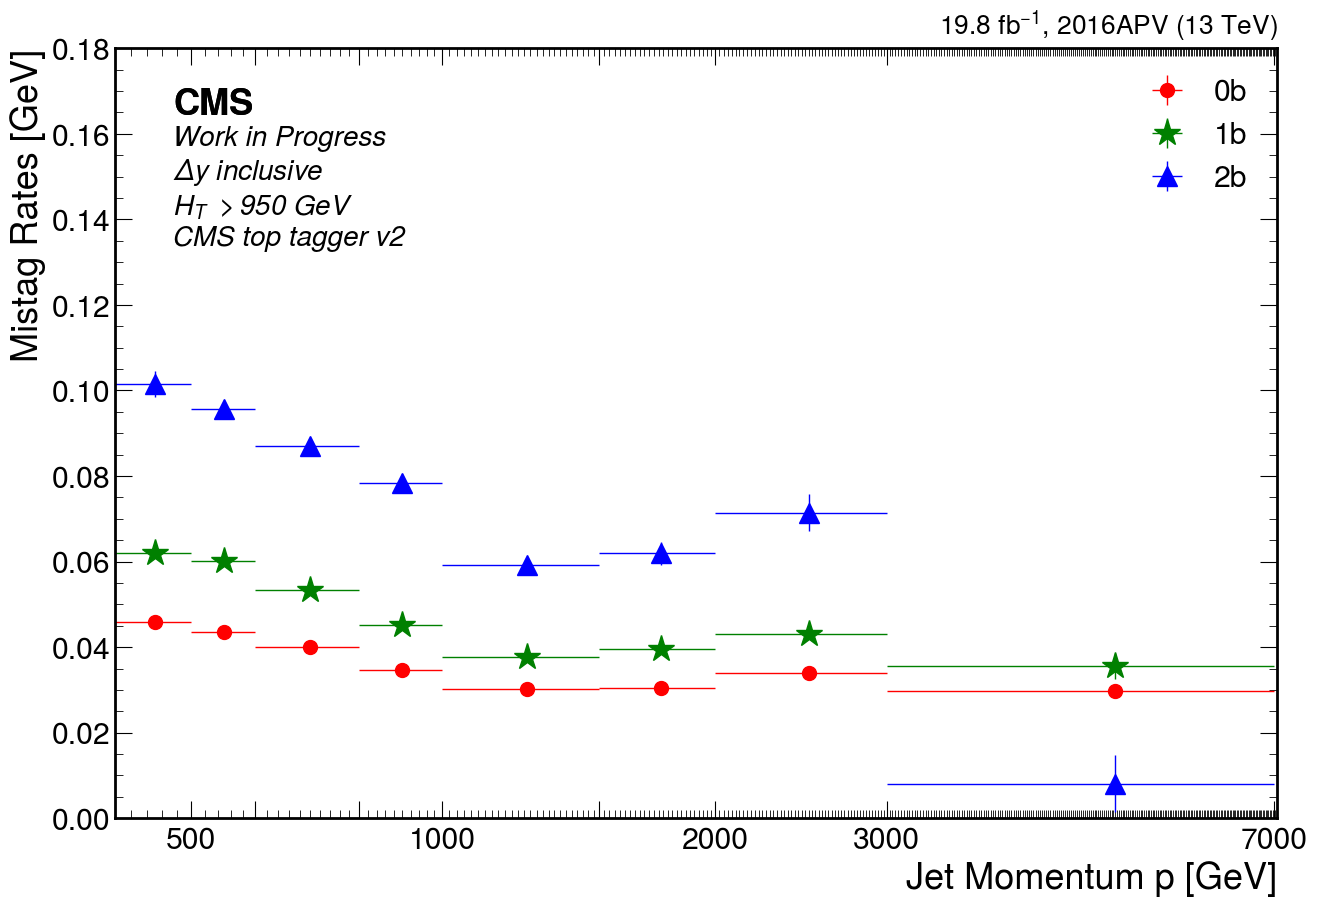

In [12]:
fig, ax = plt.subplots(
    figsize=(15,10),
    sharex=True
)

mistag0b = mistag['0b'].values
mistag1b = mistag['1b'].values
mistag2b = mistag['2b'].values

err0b = np.where(mistag['0berr'].values < 0, 0., mistag['0berr'].values)
err1b = np.where(mistag['1berr'].values < 0, 0., mistag['1berr'].values)
err2b = np.where(mistag['2berr'].values < 0, 0., mistag['2berr'].values)

bins = np.arange(len(mistag0b)+1)
pbins = np.array(mistag['jetp bins'].values)
pbins = np.append(pbins, 10000)

print(mistag0b)
print(pbins)

hep.cms.label('', data=True, lumi=luminosity[IOV]/1000, year=IOV, fontsize=20, loc=2)
# hep.cms.text('Preliminary'+'\n'
#              +r'$\Delta y$ inclusive'+'\n'+r'$H_T\ > 1400\ GeV$'+'\n'
#              +tagger,
#              fontsize=20, loc=2)
hep.cms.text('Work in Progress'+'\n'
             +r'$\Delta y$ inclusive'+'\n'+r'$H_T\ > 950\ GeV$'+'\n'
             +tagger,
             fontsize=20, loc=2)

plt.ylim(bottom = 0.0, top = 0.18)
# plt.ylim(bottom = 0.0, top = 0.26)
plt.xlim(400, 7050)

hep.histplot(mistag0b, pbins, ax=ax, xerr=True, yerr=err0b, histtype='errorbar', color='red', markersize=20)
hep.histplot(mistag1b, pbins, ax=ax, xerr=True, yerr=err1b, histtype='errorbar', color='green', marker='*', markersize=20)
hep.histplot(mistag2b, pbins, ax=ax, xerr=True, yerr=err2b, histtype='errorbar', color='blue', marker='^', markersize=15)

# ---- Optional x-axis scaling ---- #
ax.set_xscale('function', functions=(forward, inverse))
plt.xticks(np.array([400, 500, 600, 800, 1000, 1500, 2000, 3000, 7000]))
ax.set_xticklabels(['', 500, '', '', 1000, '', 2000, 3000, 7000])
ax.set_xlabel('Jet Momentum p [GeV]')
ax.set_ylabel('Mistag Rates [GeV]')
plt.legend(['0b', '1b', '2b'], loc='upper right')

# coffee = plt.text(1.0, 0.87, u"☕",
#               fontsize=50,
#               horizontalalignment='right',
#               verticalalignment='top',
#               transform=ax.transAxes
#              )

# QCDlabel = plt.text(0.85, 0.95, 'QCD Pythia 8',
#               weight='bold',
#               fontsize=20,
#               horizontalalignment='right',
#               verticalalignment='top',
#               transform=ax.transAxes
#              )

savefilename = f'../plots/images/pdf/mistagRate/'+IOV+'/mistag_'+tagger.lower().replace('top','').replace(' ','')+'.pdf'

# plt.savefig(savefilename)
# plt.savefig(savefilename.replace('pdf', 'png'))

print('saving', savefilename)
print('saving', savefilename.replace('pdf', 'png'))

plt.show()
